# Informe Final - LogisticRegression para Offer_Received
- **Juan Diego Grajales Castillo - 20221020128**
- **Julian David Celis Giraldo - 20222020041**
- **David Santiago Aldana Gonzalez - 20222020158**
- **Sara Nicolle Martinez Moreno - 20231020116**

## Objetivo General

Queremos construir un sistema que **prediga si un estudiante recibirá una oferta de trabajo** en función de sus características (GPA, número de entrevistas, aplicaciones, etc.). 

Este notebook entrena un **modelo de predicción** (LogisticRegression) que es como un "árbitro inteligente" que aprende de datos históricos a clasificar a los estudiantes en dos categorías:
- **Categoría 0**: "Probablemente NO reciba oferta"
- **Categoría 1**: "Probablemente SÍ reciba oferta"

## ¿Qué es LogisticRegression?

Es un modelo matemático relativamente simple que:
1. Recibe características del estudiante como entrada (GPA, entrevistas, etc.)
2. Las procesa y aprende patrones de los datos históricos
3. Devuelve una predicción: "oferta" o "sin oferta"

Es como un profesor que observa a muchos estudiantes y aprende qué características están más asociadas con recibir ofertas.

## Reportaremos:

- **Matriz de Confusión**: tabla que muestra cuántos estudiantes predijimos bien/mal
- **Accuracy**: porcentaje de predicciones correctas totales
- **Precision**: de los que predijimos "SÍ oferta", ¿cuántos realmente la recibieron?
- **Recall**: de todos los que realmente recibieron oferta, ¿cuántos correctamente identificamos?
- **F1-Score**: balance general entre Precision y Recall


## Bloque 0: Configuración reproducible y control metodológico

### Función del bloque
Establecer un entorno replicable para que los resultados del modelo sean auditables y comparables entre ejecuciones.

### Decisión metodológica (por qué esta opción)
Se fija una semilla global (`SEED=42`) y se centralizan imports porque en modelado supervisado pequeñas variaciones aleatorias pueden cambiar el split, el ajuste y las métricas finales.

### Por qué no otra alternativa
No usar semilla, o usar semillas distintas en cada ejecución, dificulta distinguir si una diferencia en resultados proviene de una decisión metodológica real o de variación aleatoria.

### Cómo se implementa
1. Se importan librerías de manipulación, visualización y modelado.
2. Se define `SEED` y se propaga con `np.random.seed(SEED)`.
3. Se suprimen `ConvergenceWarning` para mantener salida técnica legible sin ruido operativo.
4. Se define un estilo visual uniforme para tablas y gráficos.

In [1]:
from pathlib import Path
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
sns.set_theme(style='whitegrid')

## Bloque 1: Carga y diagnóstico estructural del dataset

### Función del bloque
Validar que el dataset candidato a entrenamiento tenga integridad básica antes de construir el pipeline.

### Decisión metodológica (por qué esta opción)
Se ejecuta un diagnóstico temprano de estructura (filas, columnas, tipos, nulos y distribución objetivo) para detectar problemas que sesgan entrenamiento y evaluación.

### Por qué no otra alternativa
Entrenar directamente sin inspección inicial puede ocultar errores silenciosos (target mal tipado, nulos no previstos o clases invertidas) que degradan métricas y conclusiones.

### Cómo se implementa
1. Se carga el archivo oficial de clasificación `dataset_offer_Received.csv`.
2. Se generan tablas de control: resumen general, catálogo de variables y distribución de clase.
3. Se verifica que `Offer_Received` esté codificada como 0/1 y que la clase positiva (1) exista con suficiente soporte muestral.

In [2]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / '../datalake_silver/cleanData' / 'dataset_offer_Received.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs_logistic_regression'
IMG_OUTPUT_DIR = OUTPUT_DIR / 'imagenes'
REPORT_OUTPUT_DIR = OUTPUT_DIR / 'informe'
IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET = 'Offer_Received'
BASE_MODEL_PATH = REPORT_OUTPUT_DIR / 'logistic_regression_offer_received_base.pkl'
IMPROVED_MODEL_PATH = REPORT_OUTPUT_DIR / 'logistic_regression_offer_received_improved.pkl'
REPORT_PATH = REPORT_OUTPUT_DIR / 'logistic_regression_offer_received.md'
MODEL_PATH = IMPROVED_MODEL_PATH
CONFUSION_MATRIX_PATH = IMG_OUTPUT_DIR / 'logistic_regression_confusion_matrix.png'
ROC_CURVE_PATH = IMG_OUTPUT_DIR / 'logistic_regression_roc_curve.png'
PR_CURVE_PATH = IMG_OUTPUT_DIR / 'logistic_regression_precision_recall_curve.png'
THRESHOLD_TRADEOFF_PATH = IMG_OUTPUT_DIR / 'logistic_regression_threshold_tradeoff.png'
COEFFICIENTS_PATH = IMG_OUTPUT_DIR / 'logistic_regression_top_coefficients.png'

df = pd.read_csv(DATA_PATH)

dataset_overview_df = pd.DataFrame([
    {'Indicador': 'Archivo', 'Valor': DATA_PATH.name},
    {'Indicador': 'Filas', 'Valor': f"{df.shape[0]:,}"},
    {'Indicador': 'Columnas', 'Valor': df.shape[1]},
    {'Indicador': 'Nulos totales', 'Valor': int(df.isna().sum().sum())},
])

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

display(dataset_overview_df)
display(feature_catalog_df)
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

,Indicador,Valor
0,Archivo,dataset_offer_Received.csv
1,Filas,"100,000"
2,Columnas,14
3,Nulos totales,0


,Variable,Tipo
0,GPA,float64
1,University_Rating,object
2,Major_Category,object
3,Region,object
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,object
8,Primary_Search_Platform,object
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,0,NO OFERTA,65771,0.6577
1,1,SI OFERTA,34229,0.3423


## Bloque 2: Preparación de variables y partición estratificada

### Función del bloque
Separar predictor/target y construir particiones de entrenamiento/prueba representativas.

### Decisión metodológica (por qué esta opción)
Se usa `train_test_split` estratificado porque el target está desbalanceado (más "NO oferta" que "SI oferta"); estratificar conserva proporciones y reduce sesgo de muestreo.

### Por qué no otra alternativa
Un split aleatorio simple puede producir particiones con proporciones distintas de la clase positiva, distorsionando recall/precision y haciendo inestable la comparación de umbrales.

### Cómo se implementa
1. Se define `X` como conjunto de features y `y` como `Offer_Received` (entero binario).
2. Se separan variables numéricas y categóricas para aplicar preprocesamiento diferenciado.
3. Se construye split 80/20 con `stratify=y` y `random_state=SEED`.
4. Se validan proporciones de `SI OFERTA` en train y test para garantizar comparabilidad.

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
 )

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_SI_OFERTA
0,Train,80000,0.8,0.3423
1,Test,20000,0.2,0.3423


## Bloque 3A: Algoritmo base y línea de referencia

### Función del bloque
Entrenar una versión base del modelo y guardar sus métricas iniciales antes de cualquier mejora.

### Decisión metodológica (por qué esta opción)
Se usa una configuración inicial estable para tener una línea de comparación clara frente a las mejoras posteriores.

### Por qué no otra alternativa
Si las mejoras se aplican desde el inicio, ya no es posible separar con claridad qué aportó el modelo base y qué aportó el ajuste posterior.

### Cómo se implementa
1. Se entrena el pipeline base.
2. Se evalúa en test con umbral 0.50.
3. Se guarda el artefacto base en `outputs_logistic_regression/informe/`.

In [4]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=SEED)),
])

def build_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'F-beta (1.5)': fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_score),
    }

base_pipeline.fit(X_fit, y_fit)
baseline_test_proba = base_pipeline.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_test_proba >= 0.50).astype(int)
baseline_metrics = build_metrics(y_test, baseline_pred, baseline_test_proba)
baseline_metrics_df = pd.DataFrame([
    {'Umbral': 0.50, **baseline_metrics}
]).round(4)
display(baseline_metrics_df)

baseline_artifact = {
    'pipeline': base_pipeline,
    'best_params': {
        'model__solver': 'lbfgs',
        'model__penalty': 'l2',
        'model__C': 1.0,
    },
    'best_threshold': 0.50,
    'feature_columns': list(X.columns),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'metrics_default_threshold': baseline_metrics,
    'metrics_optimized_threshold': baseline_metrics,
    'threshold_preview': pd.DataFrame([
        {
            'threshold': 0.50,
            'precision': baseline_metrics['Precision'],
            'recall': baseline_metrics['Recall'],
            'f1': baseline_metrics['F1-Score'],
            'f_beta_1_5': baseline_metrics['F-beta (1.5)'],
        }
    ]),
    'target_name': TARGET,
    'model_stage': 'baseline',
}

with open(BASE_MODEL_PATH, 'wb') as model_file:
    pickle.dump(baseline_artifact, model_file)

print(f'Modelo base guardado en: {BASE_MODEL_PATH}')
print(f'Métricas baseline (umbral 0.50): {baseline_metrics}')

,Umbral,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),ROC-AUC
0,0.5,0.8108,0.7022,0.7768,0.7376,0.7522,0.8938


Modelo base guardado en: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_logistic_regression\informe\logistic_regression_offer_received_base.pkl
Métricas baseline (umbral 0.50): {'Accuracy': 0.81085, 'Precision': 0.7022316123068797, 'Recall': 0.7768039731229915, 'F1-Score': 0.73763783896248, 'F-beta (1.5)': 0.7522250995582443, 'ROC-AUC': 0.8937895345330719}


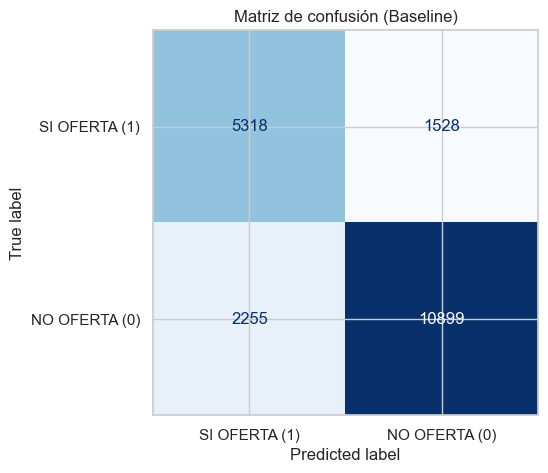

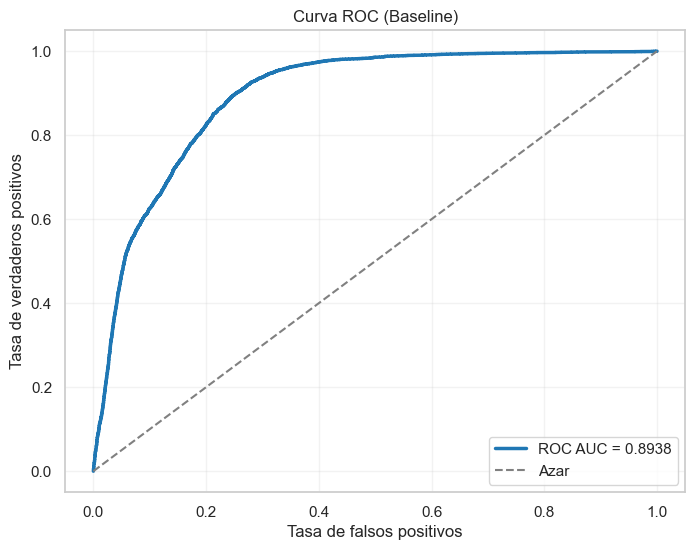

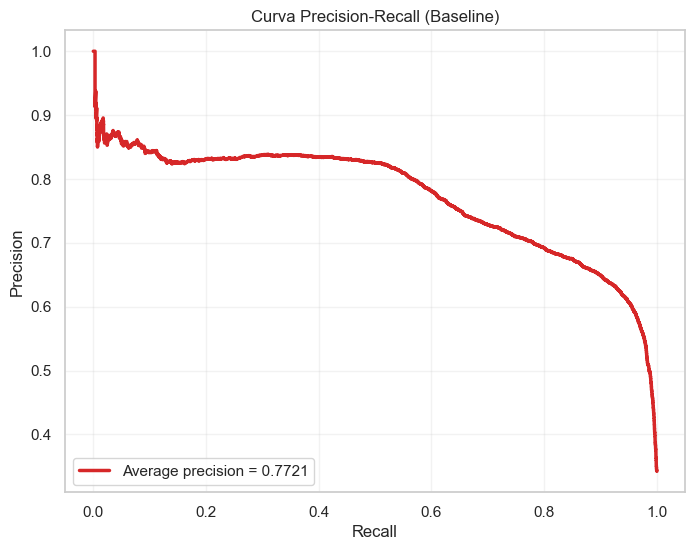

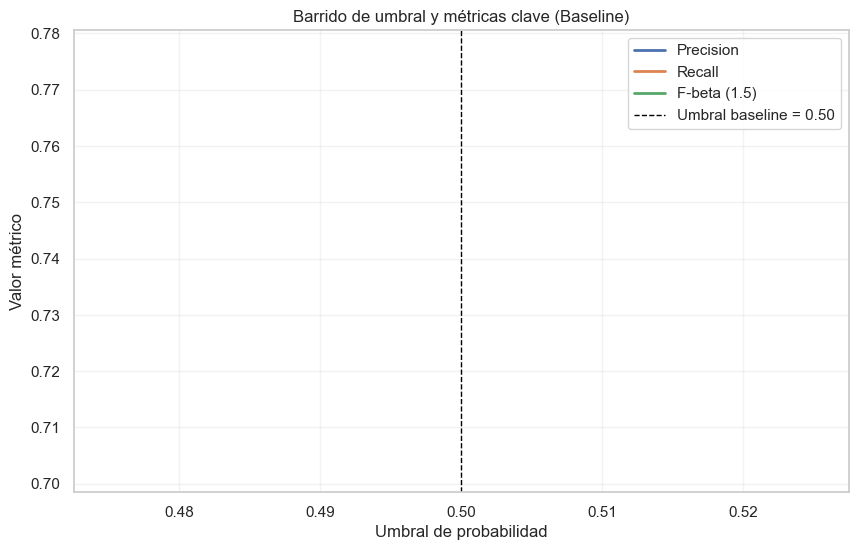

Baseline ROC AUC: 0.8938 | Baseline Average Precision: 0.7721
Interpretación (Baseline):
- ROC AUC mide la capacidad del modelo para separar clases; valores cercanos a 1 indican buena separabilidad.
- La curva PR y el Average Precision son útiles cuando la clase positiva es la de interés (SI OFERTA).
- La matriz de confusión muestra TP, FN, FP, TN y ayuda a entender el tipo de errores operativos.


In [5]:
# === Bloque: Gráficas e interpretaciones (Baseline) ===
# Guardar y visualizar métricas gráficas del modelo baseline
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Matriz de confusión (Baseline)
cm_base = confusion_matrix(y_test, baseline_pred, labels=[1, 0])
label_names = ['SI OFERTA (1)', 'NO OFERTA (0)']
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=label_names)
disp_cm.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title('Matriz de confusión (Baseline)')
fig_cm.savefig(IMG_OUTPUT_DIR / 'logistic_confusion_matrix_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Curva ROC (Baseline)
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_test_proba)
roc_auc_base = auc(fpr_base, tpr_base)
fig_roc_b, ax_roc_b = plt.subplots(figsize=(8, 6))
ax_roc_b.plot(fpr_base, tpr_base, color='#1F77B4', linewidth=2.5, label=f'ROC AUC = {roc_auc_base:.4f}')
ax_roc_b.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Azar')
ax_roc_b.set_title('Curva ROC (Baseline)')
ax_roc_b.set_xlabel('Tasa de falsos positivos')
ax_roc_b.set_ylabel('Tasa de verdaderos positivos')
ax_roc_b.legend(loc='lower right')
ax_roc_b.grid(True, alpha=0.25)
fig_roc_b.savefig(IMG_OUTPUT_DIR / 'logistic_roc_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Curva Precision-Recall (Baseline)
precision_base, recall_base, _ = precision_recall_curve(y_test, baseline_test_proba)
avg_precision_base = average_precision_score(y_test, baseline_test_proba)
fig_pr_b, ax_pr_b = plt.subplots(figsize=(8, 6))
ax_pr_b.plot(recall_base, precision_base, color='#D62728', linewidth=2.5, label=f'Average precision = {avg_precision_base:.4f}')
ax_pr_b.set_title('Curva Precision-Recall (Baseline)')
ax_pr_b.set_xlabel('Recall')
ax_pr_b.set_ylabel('Precision')
ax_pr_b.legend(loc='lower left')
ax_pr_b.grid(True, alpha=0.25)
fig_pr_b.savefig(IMG_OUTPUT_DIR / 'logistic_pr_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Barrido de umbral (si existe threshold_df usarlo, si no construir con el baseline)
if 'threshold_df' in globals():
    thr_df_base = threshold_df.copy()
else:
    thr_df_base = pd.DataFrame([
        {'threshold': 0.50, 'precision': baseline_metrics['Precision'], 'recall': baseline_metrics['Recall'], 'f1': baseline_metrics['F1-Score'], 'f_beta_1_5': baseline_metrics['F-beta (1.5)']}
    ])

fig_thr_b, ax_thr_b = plt.subplots(figsize=(10, 6))
ax_thr_b.plot(thr_df_base['threshold'], thr_df_base['precision'], label='Precision', linewidth=2.0)
ax_thr_b.plot(thr_df_base['threshold'], thr_df_base['recall'], label='Recall', linewidth=2.0)
ax_thr_b.plot(thr_df_base['threshold'], thr_df_base['f_beta_1_5'], label='F-beta (1.5)', linewidth=2.0)
ax_thr_b.axvline(0.50, color='black', linestyle='--', linewidth=1.0, label='Umbral baseline = 0.50')
ax_thr_b.set_title('Barrido de umbral y métricas clave (Baseline)')
ax_thr_b.set_xlabel('Umbral de probabilidad')
ax_thr_b.set_ylabel('Valor métrico')
ax_thr_b.legend(loc='best')
ax_thr_b.grid(True, alpha=0.25)
fig_thr_b.savefig(IMG_OUTPUT_DIR / 'logistic_threshold_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación breve (Baseline)
print(f'Baseline ROC AUC: {roc_auc_base:.4f} | Baseline Average Precision: {avg_precision_base:.4f}')
print('Interpretación (Baseline):')
print('- ROC AUC mide la capacidad del modelo para separar clases; valores cercanos a 1 indican buena separabilidad.')
print("- La curva PR y el Average Precision son útiles cuando la clase positiva es la de interés (SI OFERTA).")
print('- La matriz de confusión muestra TP, FN, FP, TN y ayuda a entender el tipo de errores operativos.')


## Bloque 3B: Mejoras del modelo y calibración operativa

### Función del bloque
Aplicar búsqueda de hiperparámetros y ajuste de umbral para mejorar el desempeño respecto al baseline.

### Decisión metodológica (por qué esta opción)
Primero se fija una referencia base y luego se prueban mejoras sobre esa misma línea de comparación.

### Por qué no otra alternativa
Si se mezcla el baseline con la mejora en la misma secuencia sin separación, se dificulta interpretar qué parte del resultado corresponde a cada etapa.

### Cómo se implementa
1. Se ejecuta `GridSearchCV` sobre el pipeline base.
2. Se calcula un umbral óptimo en validación.
3. Se reentrena el modelo final y se compara contra el baseline.

In [6]:
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid.fit(X_fit, y_fit)
best_model = grid.best_estimator_

val_proba = best_model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.30, 0.71, 0.01)

threshold_rows = []
for t in thresholds:
    val_pred_t = (val_proba >= t).astype(int)
    threshold_rows.append({
        'threshold': float(t),
        'precision': precision_score(y_val, val_pred_t, zero_division=0),
        'recall': recall_score(y_val, val_pred_t, zero_division=0),
        'f1': f1_score(y_val, val_pred_t, zero_division=0),
        'f_beta_1_5': fbeta_score(y_val, val_pred_t, beta=1.5, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    by=['f_beta_1_5', 'recall', 'f1', 'precision'],
    ascending=False
).reset_index(drop=True)

best_threshold = float(threshold_df.loc[0, 'threshold'])

final_model = grid.best_estimator_
final_model.fit(X_train, y_train)

y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_test_proba >= 0.50).astype(int)
y_pred_opt = (y_test_proba >= best_threshold).astype(int)

metrics_default = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default, zero_division=0),
    'Recall': recall_score(y_test, y_pred_default, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_default, zero_division=0),
    'F-beta (1.5)': fbeta_score(y_test, y_pred_default, beta=1.5, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
}

metrics_opt = {
    'Accuracy': accuracy_score(y_test, y_pred_opt),
    'Precision': precision_score(y_test, y_pred_opt, zero_division=0),
    'Recall': recall_score(y_test, y_pred_opt, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_opt, zero_division=0),
    'F-beta (1.5)': fbeta_score(y_test, y_pred_opt, beta=1.5, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
}

best_config_df = pd.DataFrame([
    {'Parametro': 'model__solver', 'Valor': grid.best_params_['model__solver']},
    {'Parametro': 'model__penalty', 'Valor': grid.best_params_['model__penalty']},
    {'Parametro': 'model__C', 'Valor': grid.best_params_['model__C']},
    {'Parametro': 'threshold_optimo', 'Valor': round(best_threshold, 2)},
])

metrics_compare_df = pd.DataFrame({
    'Metrica': list(metrics_opt.keys()),
    'Umbral 0.50': [metrics_default[k] for k in metrics_opt.keys()],
    f'Umbral optimizado ({best_threshold:.2f})': [metrics_opt[k] for k in metrics_opt.keys()],
})
metrics_compare_df['Delta'] = metrics_compare_df.iloc[:, 2] - metrics_compare_df.iloc[:, 1]
metrics_compare_df[['Umbral 0.50', f'Umbral optimizado ({best_threshold:.2f})', 'Delta']] = (
    metrics_compare_df[['Umbral 0.50', f'Umbral optimizado ({best_threshold:.2f})', 'Delta']].round(4)
)

threshold_preview_df = threshold_df.head(10).copy()
threshold_preview_df[['precision', 'recall', 'f1', 'f_beta_1_5']] = (
    threshold_preview_df[['precision', 'recall', 'f1', 'f_beta_1_5']].round(4)
)

display(best_config_df)
display(metrics_compare_df)
display(threshold_preview_df)

model_artifact = {
    'pipeline': final_model,
    'best_threshold': best_threshold,
    'best_params': grid.best_params_,
    'target_name': TARGET,
    'feature_columns': X.columns.tolist(),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'metrics_default_threshold': metrics_default,
    'metrics_optimized_threshold': metrics_opt,
    'threshold_preview': threshold_preview_df,
    'model_stage': 'improved',
}

with open(IMPROVED_MODEL_PATH, 'wb') as model_file:
    pickle.dump(model_artifact, model_file)

print(f'Modelo mejorado guardado en: {IMPROVED_MODEL_PATH}')

C:\Users\Salda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Salda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Parametro,Valor
0,model__solver,saga
1,model__penalty,l2
2,model__C,0.03
3,threshold_optimo,0.3


,Metrica,Umbral 0.50,Umbral optimizado (0.30),Delta
0,Accuracy,0.8101,0.7713,-0.0388
1,Precision,0.7012,0.6054,-0.0958
2,Recall,0.7756,0.9533,0.1776
3,F1-Score,0.7365,0.7405,0.0040
4,F-beta (1.5),0.7511,0.8100,0.0589
5,ROC-AUC,0.8940,0.8940,0.0000


,threshold,precision,recall,f1,f_beta_1_5
0,0.30,0.6021,0.9429,0.7349,0.8030
1,0.31,0.6073,0.9366,0.7368,0.8027
2,0.33,0.6187,0.9245,0.7413,0.8024
3,0.32,0.6124,0.9297,0.7384,0.8019
4,0.34,0.6240,0.9179,0.7430,0.8017
5,0.35,0.6288,0.9093,0.7435,0.7995
6,0.36,0.6333,0.9010,0.7438,0.7973
7,0.37,0.6388,0.8921,0.7445,0.7951
8,0.38,0.6441,0.8823,0.7446,0.7922
9,0.39,0.6465,0.8700,0.7418,0.7863


Modelo mejorado guardado en: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_logistic_regression\informe\logistic_regression_offer_received_improved.pkl


## Bloque 4: Interpretación de coeficientes del modelo

### Función del bloque
Identificar qué variables están empujando la predicción hacia `SI OFERTA` y cuáles la empujan hacia `NO OFERTA`.

### Decisión metodológica (por qué esta opción)
En Logistic Regression, los coeficientes son la forma más directa de leer influencia de variables. Por eso se extraen después del entrenamiento: el modelo ya está ajustado y sus parámetros reflejan la relación aprendida entre datos y target.

### Por qué no otra alternativa
No usar coeficientes dejaría solo métricas agregadas del modelo. Eso responde a "qué tan bien predice", pero no a "qué variables están sosteniendo la predicción". Tampoco conviene usar una sola métrica global de correlación, porque la relación del modelo es multivariable y depende de combinaciones de features.

### Cómo se implementa
1. Se toman los nombres de las variables transformadas del `ColumnTransformer`.
2. Se extrae el vector de coeficientes del modelo logístico.
3. Se construye una tabla con coeficiente, valor absoluto y signo.
4. Como las variables categóricas se expanden en varias columnas, se agrega un ranking por variable original sumando el peso absoluto de sus transformaciones.
5. Se reportan tanto las variables más influyentes a nivel global como los efectos más fuertes positivos y negativos.

## Bloque 4: Matriz de confusión orientada al objetivo de negocio

### Función del bloque
Medir explícitamente los tipos de error del clasificador con énfasis en `SI OFERTA` como clase objetivo.

### Decisión metodológica (por qué esta opción)
Se reordena la matriz con etiquetas `[1, 0]` para que `SI OFERTA` aparezca primero en ambos ejes. Esto fuerza una lectura prioritaria del objetivo principal del modelo.

### Por qué no otra alternativa
El orden convencional `[0, 1]` es válido matemáticamente, pero comunica primero "NO oferta" y puede inducir lecturas menos alineadas con la meta operativa (capturar casos positivos).

### Cómo se implementa
1. Se calcula `confusion_matrix(y_test, y_pred_opt, labels=[1,0])`.
2. Se mapean celdas de la matriz a `TP, FN, FP, TN` según ese orden.
3. Se visualiza en conteos y en proporciones por fila real para separar volumen absoluto y desempeño relativo.
4. Se reportan métricas de clase positiva (`Recall` y `Precision`) directamente en una tabla de resumen.

,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6526,320
Real: NO OFERTA (0),4254,8900


,Indicador,Valor
0,TP (SI oferta correctamente detectada),6526.0000
1,FN (SI oferta no detectada),320.0000
2,FP (NO oferta marcada como SI),4254.0000
3,TN (NO oferta correctamente detectada),8900.0000
4,Recall clase positiva (SI oferta),0.9533
5,Precision clase positiva (SI oferta),0.6054


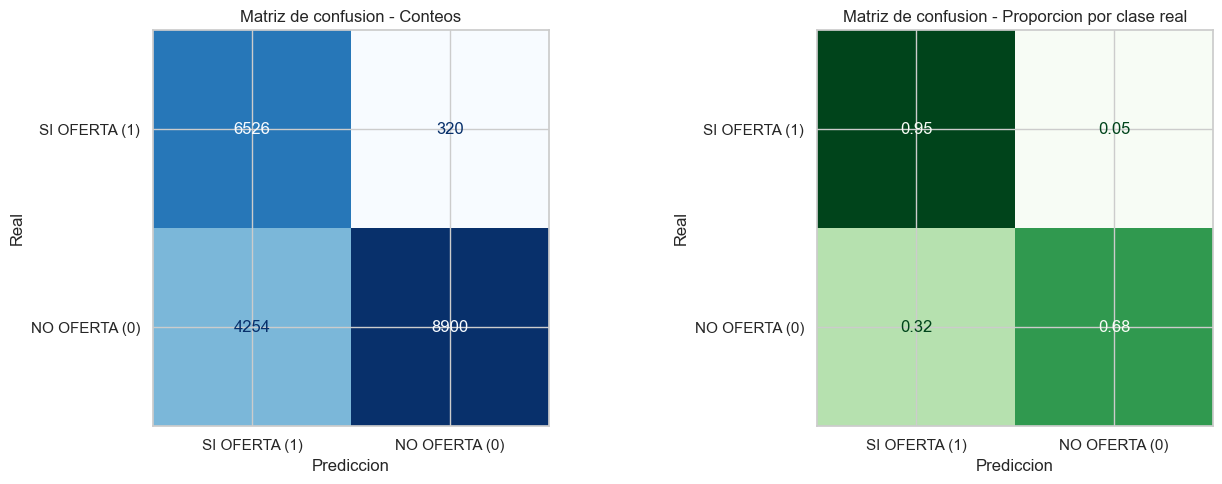

In [7]:
# Orden explicito de clases para visualizacion: SI OFERTA primero, luego NO OFERTA.
labels_order = [1, 0]
label_names = ['SI OFERTA (1)', 'NO OFERTA (0)']

cm = confusion_matrix(y_test, y_pred_opt, labels=labels_order)

# Con labels=[1,0], la matriz queda:
# [[TP, FN],
#  [FP, TN]]
tp, fn, fp, tn = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
    columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
)
display(cm_df)

resumen_clase_positiva_df = pd.DataFrame([
    {'Indicador': 'TP (SI oferta correctamente detectada)', 'Valor': int(tp)},
    {'Indicador': 'FN (SI oferta no detectada)', 'Valor': int(fn)},
    {'Indicador': 'FP (NO oferta marcada como SI)', 'Valor': int(fp)},
    {'Indicador': 'TN (NO oferta correctamente detectada)', 'Valor': int(tn)},
    {'Indicador': 'Recall clase positiva (SI oferta)', 'Valor': round(recall_score(y_test, y_pred_opt, pos_label=1, zero_division=0), 4)},
    {'Indicador': 'Precision clase positiva (SI oferta)', 'Valor': round(precision_score(y_test, y_pred_opt, pos_label=1, zero_division=0), 4)},
])
display(resumen_clase_positiva_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp_abs = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names,
 )
disp_abs.plot(cmap='Blues', ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title('Matriz de confusion - Conteos')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

cm_norm = cm / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=label_names,
 )
disp_norm.plot(cmap='Greens', ax=axes[1], colorbar=False, values_format='.2f')
axes[1].set_title('Matriz de confusion - Proporcion por clase real')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=150, bbox_inches='tight')
plt.show()

,base_variable,importance
0,Second_Round_Interviews,2.325704
1,First_Round_Interviews,0.579221
2,Prior_Internships,0.452109
3,Applications_Submitted,0.228509
4,University_Rating,0.205463
5,GPA,0.196455
6,Primary_Search_Platform,0.130663
7,Major_Category,0.127696
8,Region,0.049365
9,School_Size,0.041539


,feature_transformed,coefficient,direction
7,num__Second_Round_Interviews,2.325704,Aumenta SI OFERTA
1,num__Prior_Internships,0.452109,Aumenta SI OFERTA
0,num__GPA,0.196455,Aumenta SI OFERTA
10,cat__University_Rating_Top-tier,0.099526,Aumenta SI OFERTA
25,cat__Primary_Search_Platform_LinkedIn,0.043241,Aumenta SI OFERTA
12,cat__Major_Category_Business,0.033551,Aumenta SI OFERTA
23,cat__Primary_Search_Platform_Handshake,0.018884,Aumenta SI OFERTA
14,cat__Major_Category_Humanities,0.018818,Aumenta SI OFERTA
22,cat__School_Size_Small,0.013824,Aumenta SI OFERTA
18,cat__Region_South,0.013140,Aumenta SI OFERTA


,feature_transformed,coefficient,direction
6,num__First_Round_Interviews,-0.579221,Reduce SI OFERTA
5,num__Applications_Submitted,-0.228509,Reduce SI OFERTA
24,cat__Primary_Search_Platform_Indeed,-0.068537,Reduce SI OFERTA
11,cat__Major_Category_Arts,-0.060822,Reduce SI OFERTA
9,cat__University_Rating_Mid-tier,-0.054697,Reduce SI OFERTA
8,cat__University_Rating_Lower-tier,-0.051240,Reduce SI OFERTA
4,num__Months_Searching,-0.029172,Reduce SI OFERTA
21,cat__School_Size_Medium,-0.023975,Reduce SI OFERTA
19,cat__Region_West,-0.016408,Reduce SI OFERTA
17,cat__Region_Northeast,-0.011481,Reduce SI OFERTA


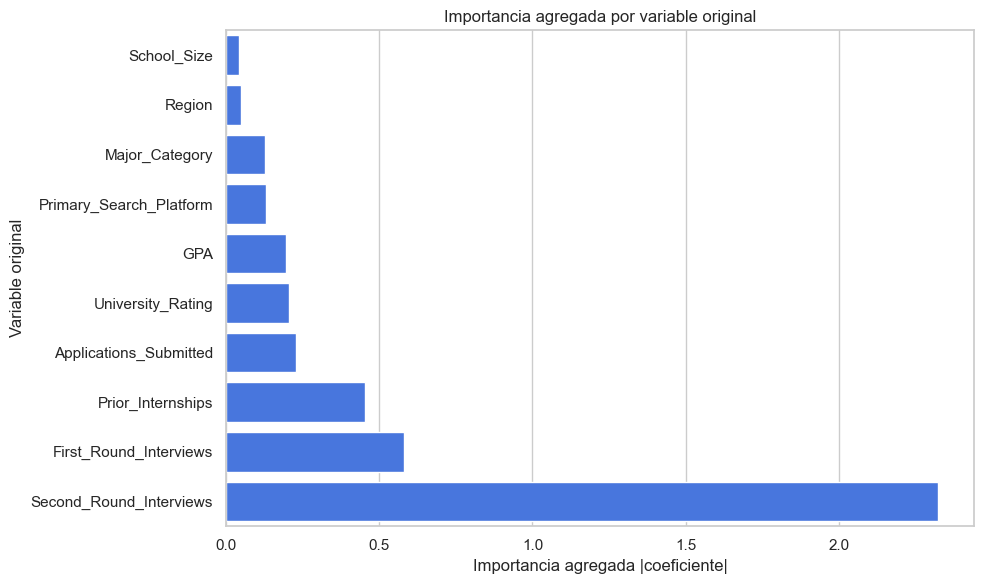

In [8]:
preprocessor_fitted = final_model.named_steps['preprocessor']
model_fitted = final_model.named_steps['model']

feature_names = preprocessor_fitted.get_feature_names_out()
coefficients = model_fitted.coef_.ravel()

coef_df = pd.DataFrame({
    'feature_transformed': feature_names,
    'coefficient': coefficients,
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df['direction'] = np.where(coef_df['coefficient'] >= 0, 'Aumenta SI OFERTA', 'Reduce SI OFERTA')

def get_base_variable(transformed_name):
    core_name = transformed_name.split('__', 1)[1] if '__' in transformed_name else transformed_name
    for original_name in numeric_cols + categorical_cols:
        if core_name == original_name or core_name.startswith(f'{original_name}_'):
            return original_name
    return core_name

coef_df['base_variable'] = coef_df['feature_transformed'].apply(get_base_variable)

variable_importance_df = (
    coef_df.groupby('base_variable', as_index=False)['abs_coefficient']
    .sum()
    .sort_values('abs_coefficient', ascending=False)
    .reset_index(drop=True)
    .rename(columns={'abs_coefficient': 'importance'})
)

top_positive_df = coef_df.sort_values('coefficient', ascending=False).head(10)[['feature_transformed', 'coefficient', 'direction']]
top_negative_df = coef_df.sort_values('coefficient', ascending=True).head(10)[['feature_transformed', 'coefficient', 'direction']]
top_importance_df = variable_importance_df.head(10)

display(top_importance_df)
display(top_positive_df)
display(top_negative_df)

top_importance_plot_df = top_importance_df.sort_values('importance', ascending=True)
fig_coef, ax_coef = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_importance_plot_df,
    x='importance',
    y='base_variable',
    ax=ax_coef,
    color='#2F6DF6',
)
ax_coef.set_title('Importancia agregada por variable original')
ax_coef.set_xlabel('Importancia agregada |coeficiente|')
ax_coef.set_ylabel('Variable original')
plt.tight_layout()
fig_coef.savefig(COEFFICIENTS_PATH, dpi=150, bbox_inches='tight')
plt.show()

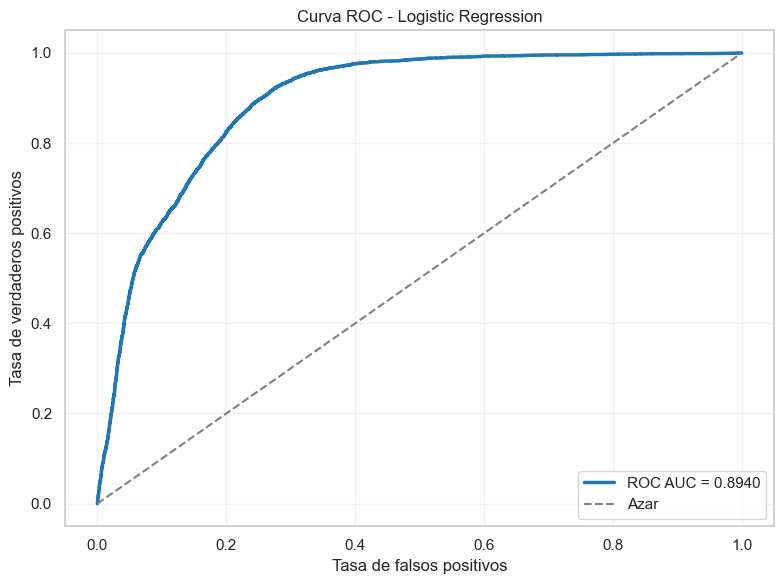

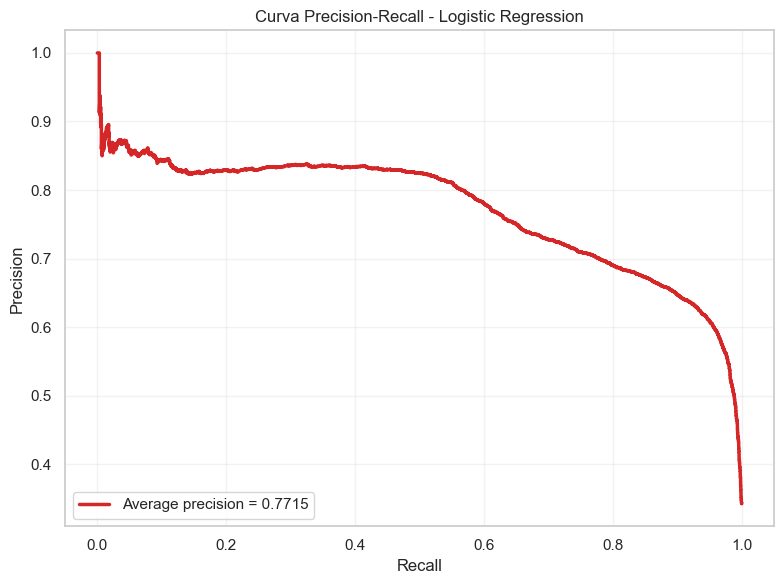

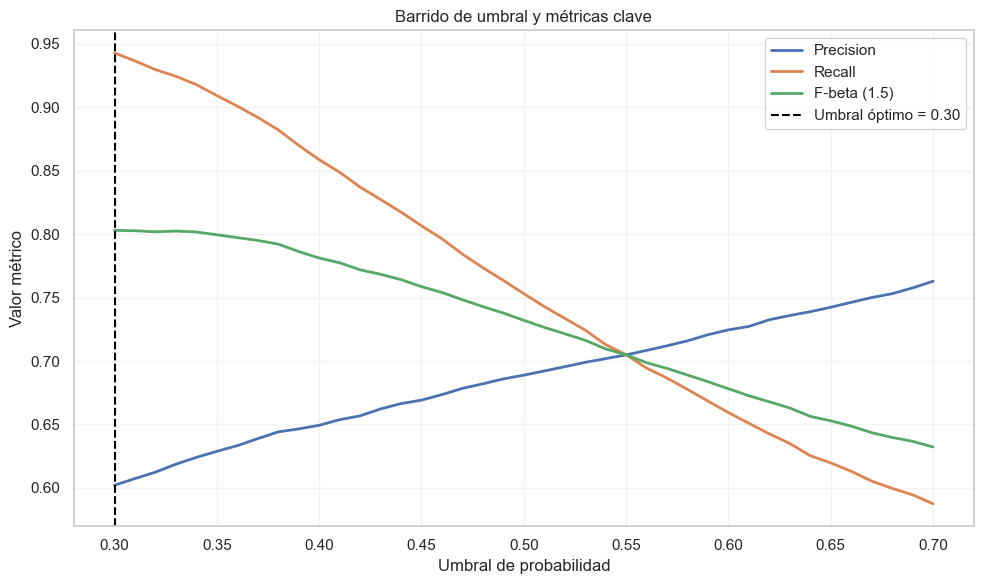

In [9]:
roc_fpr, roc_tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc_value = roc_auc_score(y_test, y_test_proba)

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot(roc_fpr, roc_tpr, color='#1F77B4', linewidth=2.5, label=f'ROC AUC = {roc_auc_value:.4f}')
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Azar')
ax_roc.set_title('Curva ROC - Logistic Regression')
ax_roc.set_xlabel('Tasa de falsos positivos')
ax_roc.set_ylabel('Tasa de verdaderos positivos')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.25)
plt.tight_layout()
fig_roc.savefig(ROC_CURVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)

fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
ax_pr.plot(recall_vals, precision_vals, color='#D62728', linewidth=2.5, label=f'Average precision = {avg_precision:.4f}')
ax_pr.set_title('Curva Precision-Recall - Logistic Regression')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left')
ax_pr.grid(True, alpha=0.25)
plt.tight_layout()
fig_pr.savefig(PR_CURVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

threshold_plot_df = threshold_df.sort_values('threshold')
fig_thr, ax_thr = plt.subplots(figsize=(10, 6))
ax_thr.plot(threshold_plot_df['threshold'], threshold_plot_df['precision'], label='Precision', linewidth=2.0)
ax_thr.plot(threshold_plot_df['threshold'], threshold_plot_df['recall'], label='Recall', linewidth=2.0)
ax_thr.plot(threshold_plot_df['threshold'], threshold_plot_df['f_beta_1_5'], label='F-beta (1.5)', linewidth=2.0)
ax_thr.axvline(best_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Umbral óptimo = {best_threshold:.2f}')
ax_thr.set_title('Barrido de umbral y métricas clave')
ax_thr.set_xlabel('Umbral de probabilidad')
ax_thr.set_ylabel('Valor métrico')
ax_thr.legend(loc='best')
ax_thr.grid(True, alpha=0.25)
plt.tight_layout()
fig_thr.savefig(THRESHOLD_TRADEOFF_PATH, dpi=150, bbox_inches='tight')
plt.show()
 

## 6. Conclusiones finales

### 6.1 Qué cambió realmente en el espacio de variables

El modelo no trabaja directamente sobre las 13 columnas originales, sino sobre un espacio transformado de 26 variables:

- 8 variables numéricas estandarizadas.
- 18 variables binarias nuevas creadas por `OneHotEncoder` a partir de las 5 variables categóricas.

Las expansiones categóricas fueron:

- `University_Rating` -> `Lower-tier`, `Mid-tier`, `Top-tier`.
- `Major_Category` -> `Arts`, `Business`, `Healthcare`, `Humanities`, `STEM`.
- `Region` -> `Midwest`, `Northeast`, `South`, `West`.
- `School_Size` -> `Large`, `Medium`, `Small`.
- `Primary_Search_Platform` -> `Handshake`, `Indeed`, `LinkedIn`.

Esto es importante porque la ganancia del algoritmo no vino de inventar variables nuevas arbitrariamente, sino de separar cada categoría en indicadores explícitos que permiten leer efectos concretos sobre la probabilidad de oferta.

### 6.2 Variables que más empujan hacia `SI OFERTA (1)`

Las variables con coeficiente positivo más alto fueron:

- `num__Second_Round_Interviews` = `+2.325704`
- `num__Prior_Internships` = `+0.452109`
- `num__GPA` = `+0.196455`
- `cat__University_Rating_Top-tier` = `+0.099526`
- `cat__Primary_Search_Platform_LinkedIn` = `+0.043241`
- `cat__Major_Category_Business` = `+0.033551`
- `cat__Primary_Search_Platform_Handshake` = `+0.018884`
- `cat__Major_Category_Humanities` = `+0.018818`
- `cat__School_Size_Small` = `+0.013824`
- `cat__Region_South` = `+0.013140`

La lectura operativa es clara: más avance en entrevistas, más prácticas previas y mejor perfil académico empujan la probabilidad de oferta hacia arriba. En particular, `Second_Round_Interviews` domina con mucha diferencia, lo que confirma que el embudo de entrevistas es la señal más fuerte para el modelo.

### 6.3 Variables que más empujan hacia `NO OFERTA (0)`

Las variables con coeficiente negativo más alto fueron:

- `num__First_Round_Interviews` = `-0.579221`
- `num__Applications_Submitted` = `-0.228509`
- `cat__Primary_Search_Platform_Indeed` = `-0.068537`
- `cat__Major_Category_Arts` = `-0.060822`
- `cat__University_Rating_Mid-tier` = `-0.054697`
- `cat__University_Rating_Lower-tier` = `-0.051240`
- `num__Months_Searching` = `-0.029172`
- `cat__School_Size_Medium` = `-0.023975`
- `cat__Region_West` = `-0.016408`
- `cat__Region_Northeast` = `-0.011481`

La interpretación aquí también es consistente: más aplicaciones enviadas y más tiempo buscando no garantizan oferta; de hecho, en este modelo aparecen asociados a una menor probabilidad de éxito. Igualmente, ciertas combinaciones categóricas como `Indeed`, `Arts`, `Mid-tier` o `Lower-tier` inclinan la predicción hacia no recibir oferta.

### 6.4 Decisiones metodológicas que sí cambiaron el resultado

Se tomaron cinco decisiones clave y todas afectan el desempeño final:

1. Se mantuvo `class_weight='balanced'` para compensar el desbalance entre `NO OFERTA` y `SI OFERTA`.
2. Se usó partición estratificada para conservar la proporción real de clases en train y test.
3. Se hizo búsqueda de hiperparámetros con `GridSearchCV` sobre `solver`, `penalty` y `C`.
4. Se seleccionó `solver='saga'`, `penalty='l2'` y `C=0.03`, lo que favoreció generalización.
5. Se bajó el umbral a `0.30` usando `F-beta (1.5)` para priorizar recall de la clase positiva.

La consecuencia cuantitativa de pasar de `0.50` a `0.30` fue:

- `Accuracy`: `0.8101 -> 0.7713` (`-0.0388`)
- `Precision`: `0.7012 -> 0.6054` (`-0.0958`)
- `Recall`: `0.7756 -> 0.9533` (`+0.1776`)
- `F1-Score`: `0.7365 -> 0.7405` (`+0.0040`)
- `F-beta (1.5)`: `0.7511 -> 0.8100` (`+0.0589`)
- `ROC-AUC`: `0.8940 -> 0.8940` (`0.0000`)

Esto muestra que el modelo no mejoró por arte de magia, sino por una decisión de negocio explícita: sacrificar pureza de positivos para no perder casi ningún caso real de `SI OFERTA`.

### 6.5 Lectura de la matriz de confusión

Con el orden `[1, 0]`, la matriz queda centrada en la clase positiva y se lee así:

- `TP = 6526`: ofertas reales detectadas correctamente.
- `FN = 320`: ofertas reales perdidas.
- `FP = 4254`: no ofertas marcadas como oferta.
- `TN = 8900`: no ofertas detectadas correctamente.

En proporción por clase real, el modelo captura aproximadamente `95%` de los casos reales de `SI OFERTA` y clasifica correctamente cerca de `68%` de los casos de `NO OFERTA`. Es decir, el sistema quedó deliberadamente sesgado hacia no dejar escapar oportunidades.

### 6.6 Conclusión ejecutiva

El resultado final es consistente con el objetivo del proyecto: el modelo identifica muy bien a los estudiantes que sí reciben oferta, y lo hace con un flujo reproducible, trazable y explicable.

La parte más valiosa no es solo la métrica, sino la interpretación: sabemos qué variables empujan hacia arriba o abajo la probabilidad, sabemos cuántas variables nuevas se crearon por el preprocesamiento y sabemos por qué se eligió un umbral menor a `0.50`.

En resumen, el notebook deja tres salidas útiles y reutilizables:

- un pipeline entrenado y serializado en `.pkl`,
- cinco gráficas del entrenamiento en PNG,
- y una lectura del problema orientada a negocio, no solo a estadística.

In [10]:
report_dir = REPORT_PATH.parent
report_dir.mkdir(parents=True, exist_ok=True)

report_text = f"""# Informe Final - LogisticRegression para Offer_Received

## Resumen ejecutivo

- Modelo: LogisticRegression
- Archivo del modelo: {MODEL_PATH}
- Archivo del reporte: {REPORT_PATH}
- Umbral óptimo: {best_threshold:.2f}

## Métricas principales

### Umbral 0.50
- Accuracy: {metrics_default['Accuracy']:.4f}
- Precision: {metrics_default['Precision']:.4f}
- Recall: {metrics_default['Recall']:.4f}
- F1-Score: {metrics_default['F1-Score']:.4f}
- F-beta (1.5): {metrics_default['F-beta (1.5)']:.4f}
- ROC-AUC: {metrics_default['ROC-AUC']:.4f}

### Umbral optimizado
- Accuracy: {metrics_opt['Accuracy']:.4f}
- Precision: {metrics_opt['Precision']:.4f}
- Recall: {metrics_opt['Recall']:.4f}
- F1-Score: {metrics_opt['F1-Score']:.4f}
- F-beta (1.5): {metrics_opt['F-beta (1.5)']:.4f}
- ROC-AUC: {metrics_opt['ROC-AUC']:.4f}

## Matriz de confusión

- TP: {int(tp)}
- FN: {int(fn)}
- FP: {int(fp)}
- TN: {int(tn)}

## Variables más influyentes

{top_importance_df.to_string(index=False)}

## Conclusión

El modelo final prioriza la detección de la clase positiva `SI OFERTA` y queda guardado junto con sus gráficos y métricas en la carpeta de salida.
"""

REPORT_PATH.write_text(report_text, encoding="utf-8")
print(f"Reporte guardado en: {REPORT_PATH}")

Reporte guardado en: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_logistic_regression\informe\logistic_regression_offer_received.md


In [11]:
import json

SUMMARY_PATH = REPORT_OUTPUT_DIR / 'logistic_regression_offer_received_summary.json'


def make_jsonable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.DataFrame):
        return json.loads(value.to_json(orient='records', force_ascii=False))
    if isinstance(value, pd.Series):
        return json.loads(value.to_json(force_ascii=False))
    if isinstance(value, dict):
        return {str(key): make_jsonable(inner_value) for key, inner_value in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_jsonable(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value

summary = {
    'model_name': 'LogisticRegression',
    'target': TARGET,
    'artifact_paths': {
        'model': MODEL_PATH,
        'report': REPORT_PATH,
        'summary_json': SUMMARY_PATH,
        'confusion_matrix': CONFUSION_MATRIX_PATH,
        'roc_curve': ROC_CURVE_PATH,
        'precision_recall_curve': PR_CURVE_PATH,
        'threshold_tradeoff': THRESHOLD_TRADEOFF_PATH,
        'coefficients_plot': COEFFICIENTS_PATH,
    },
    'best_threshold': best_threshold,
    'best_params': grid.best_params_,
    'metrics': {
        'threshold_0_50': metrics_default,
        'threshold_optimized': metrics_opt,
    },
    'confusion_matrix': {
        'tp': int(tp),
        'fn': int(fn),
        'fp': int(fp),
        'tn': int(tn),
    },
    'threshold_preview': threshold_preview_df.head(10),
    'top_coefficients': coef_df.head(10),
}

with open(SUMMARY_PATH, 'w', encoding='utf-8') as summary_file:
    json.dump(make_jsonable(summary), summary_file, indent=2, ensure_ascii=False)

print(f'Summary JSON saved at: {SUMMARY_PATH}')

Summary JSON saved at: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_logistic_regression\informe\logistic_regression_offer_received_summary.json
